<a href="https://colab.research.google.com/github/eisbetterthanpi/RA/blob/main/scrape_teams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q playwright
!playwright install chromium # chromium firefox webkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 MB 13.7 MB/s eta 0:00:00
163.5 MiB [] 0% 124.4s163.5 MiB [] 0% 49.0s163.5 MiB [] 0% 31.6s163.5 MiB [] 0% 22.3s163.5 MiB [] 0% 11.8s163.5 MiB [] 1% 7.3s163.5 MiB [] 1% 5.4s163.5 MiB [] 2% 4.9s163.5 MiB [] 2% 4.3s163.5 MiB [] 3% 4.1s163.5 MiB [] 4% 3.6s163.5 MiB [] 4% 3.5s163.5 MiB [] 5% 3.4s163.5 MiB [] 6% 3.3s163.5 MiB [] 6% 3.5s163.5 MiB [] 6% 3.7s163.5 MiB [] 7% 3.7s163.5 MiB [] 7% 3.6s163.5 MiB [] 8% 3.5s163.5 MiB [] 9% 3.3s163.5 MiB [] 10% 3.2s163.5 MiB [] 10% 3.3s163.5 MiB [] 11% 3.1s163.5 MiB [] 12% 2.9s163.5 MiB [] 13% 2.7s163.5 MiB [] 13% 2.8s163.5 MiB [] 14% 2.7s163.5 MiB [] 15% 2.6s163.5 MiB [] 16% 2.6s163.5 MiB [] 17% 2.5s163.5 MiB [] 17% 2.6s163.5 MiB [] 18% 2.5s163.5 MiB [] 19% 2.4s163.5 MiB [] 20% 2.3s163.5 MiB [] 21% 2.2s163.5 MiB [] 22% 2.2s163.5 MiB [] 23% 2.1s163.5 MiB [] 24% 2.0s163.5 MiB [] 25% 2.0s163.5 MiB [] 26% 1.9s163.5 MiB [] 27% 1.9s163.5 MiB [] 27% 2.0s163.5 MiB [] 28% 1.9s163.5 MiB [] 29% 1.9s163.5 MiB [

In [ ]:
# @title playwright async
# https://github.com/microsoft/playwright-python
import asyncio
from playwright.async_api import async_playwright

path='/content/screenshot.png'
async def main(url):
    async with async_playwright() as p:
        browser = await p.chromium.launch() # p.chromium, p.firefox, p.webkit

        context = await browser.new_context()
        context.add_cookies([
            {
                'name': 'authtoken',
                'value': 'Bearer%3DeyJ0eXAiOiJKV1QiLCJub25jZSI6ImQyTHlfR3lFaFY5N3gxRjRqZGx0THM3ckRFWXVCdUFqMHNjUGItdWxYQWsiLCJhbGciOiJSUzI1NiIsIng1dCI6ImltaTBZMnowZFlLeEJ0dEFxS19UdDVoWUJUayIsImtpZCI6ImltaTBZMnowZFlLeEJ0dEFxS19UdDVoWUJUayJ9.eyJhdWQiOiJodHRwczovL2FwaS5zcGFjZXMuc2t5cGUuY29tIiwiaXNzIjoiaHR0cHM6Ly9zdHMud2luZG93cy5uZXQvNWJhNWVmNWUtMzEwOS00ZTc3LTg1YmQtY2ZlYjBkMzQ3ZTgyLyIsImlhdCI6MTczOTMzNDQ5MywibmJmIjoxNzM5MzM0NDkzLCJleHAiOjE3Mzk0MTYzMjIsImFjY3QiOjAsImFjciI6IjEiLCJhaW8iOiJBVlFBcS84WkFBQUF5TXdpSEJtOEVtR0V2ZkNVOVVuRnZVbXRYdXhIa3ZaRnM1MkRCNnhhSSthSkR4UkZzYkNHRWxtSEkvbFdzT3VSRXRsYnh1dE9wTXo4OEwrbm9RRDhnYVhYTjlua2FpWkNFNmRab01aSmo1Yz0iLCJhbXIiOlsicHdkIiwibWZhIl0sImFwcGlkIjoiNWUzY2U2YzAtMmIxZi00Mjg1LThkNGItNzVlZTc4Nzg3MzQ2IiwiYXBwaWRhY3IiOiIwIiwiYXV0aF90aW1lIjoxNzM5MzM0Nzc4LCJjdHJ5IjoiU0ciLCJmYW1pbHlfbmFtZSI6Ik9uZyIsImdpdmVuX25hbWUiOiJNYXR0aGV3IFN6ZSBZaSIsImlkdHlwIjoidXNlciIsImlwYWRkciI6IjEzNy4xMzIuMjcuMzUiLCJuYW1lIjoiTWF0dGhldyBPbmcgU3plIFlpIiwib2lkIjoiODU3NDM5NWMtMzc0My00YTkyLWIwMjUtNGVhZTk1ZGRmOTMwIiwib25wcmVtX3NpZCI6IlMtMS01LTIxLTQ4MjMxMTc4Ny0xODY5NjE4NjI2LTYxNTU4MzAxNi00NjM1NjUiLCJwdWlkIjoiMTAwMzIwMDQzQUQ5NUI0RiIsInJoIjoiMS5BVlFBWHUtbFd3a3hkMDZGdmNfckRUUi1nbGY5RmN4c0xCZEJxSXlEc2RWclM3NVVBSWhVQUEuIiwic2NwIjoiQXV0aG9yaXphdGlvbi5SZWFkV3JpdGUgUmVnaW9uLlJlYWRXcml0ZSB1c2VyX2ltcGVyc29uYXRpb24iLCJzaWQiOiIwMDIwNjEyOS0wOTBiLWI4MjktYmE3ZC1lMjdkNzE2YWY5MzUiLCJzaWduaW5fc3RhdGUiOlsiaW5rbm93bm50d2siXSwic3ViIjoiNGVmV3RVS0ZtUXFzcm5QVXdiWUl4MmV4YlNvTm95cXVQMjljQXJuRkhkWSIsInRlbmFudF9jdHJ5IjoiU0ciLCJ0aWQiOiI1YmE1ZWY1ZS0zMTA5LTRlNzctODViZC1jZmViMGQzNDdlODIiLCJ1bmlxdWVfbmFtZSI6Im0ub0BudXMuZWR1LnNnIiwidXBuIjoibS5vQG51cy5lZHUuc2ciLCJ1dGkiOiJoWnR3a2ExZmxrU3h1RVpSSlBvbUFBIiwidmVyIjoiMS4wIiwid2lkcyI6WyJiNzlmYmY0ZC0zZWY5LTQ2ODktODE0My03NmIxOTRlODU1MDkiXSwieG1zX2NjIjpbIkNQMSJdLCJ4bXNfaWRyZWwiOiIxOCAxIiwieG1zX3BmdGV4cCI6MTczOTQyNjA2NCwieG1zX3NzbSI6IjEifQ.YjuQM8rynmvIlFmYkPJlA2y0b5J18rqnG6M83LhVvX_gzTl6bJ8YiL0ev6kh8fp5EPviP6opdGltzPfrHCsWTYqHAYslG7z9XAYGgTviFuf3aNXBkWJUr4m5nfqEJibpVCFGVDD6Krs5YXzsas_dBF9CtUjDEf4R8d9v43zuGHTmXhoBXaZOkR-JgzMPInjT1oglUDluB3WB-ZYj85TCGaqYkeMFMZkwaTC97CP-6qfYV-FkZ13liRs7mJm42dBTv2XYBUs84QFds7xTCjlvWzbJIsMI53kZwThqullSwG6fo1E5KYqhsf3gQ38oGkI4QOFVB3h86JzaYd_Er5XkqQ%26origin%3Dhttps%3A%2F%2Fteams.microsoft.com',
                'domain': 'teams.microsoft.com',
                'path': '/api/mt/part/apac-02/beta/users/8574395c-3743-4a92-b025-4eae95ddf930'
            },
            ])
        page = await context.new_page()
        await page.goto('https://teams.microsoft.com/v2/?tenantId=5ba5ef5e-3109-4e77-85bd-cfeb0d347e82')
        await page.screenshot(path=path)
        await browser.close()

# url = 'http://playwright.dev'
# asyncio.run(main(url)) # in script
await main(url) # in colab

from IPython.display import Image, display
display(Image(path))



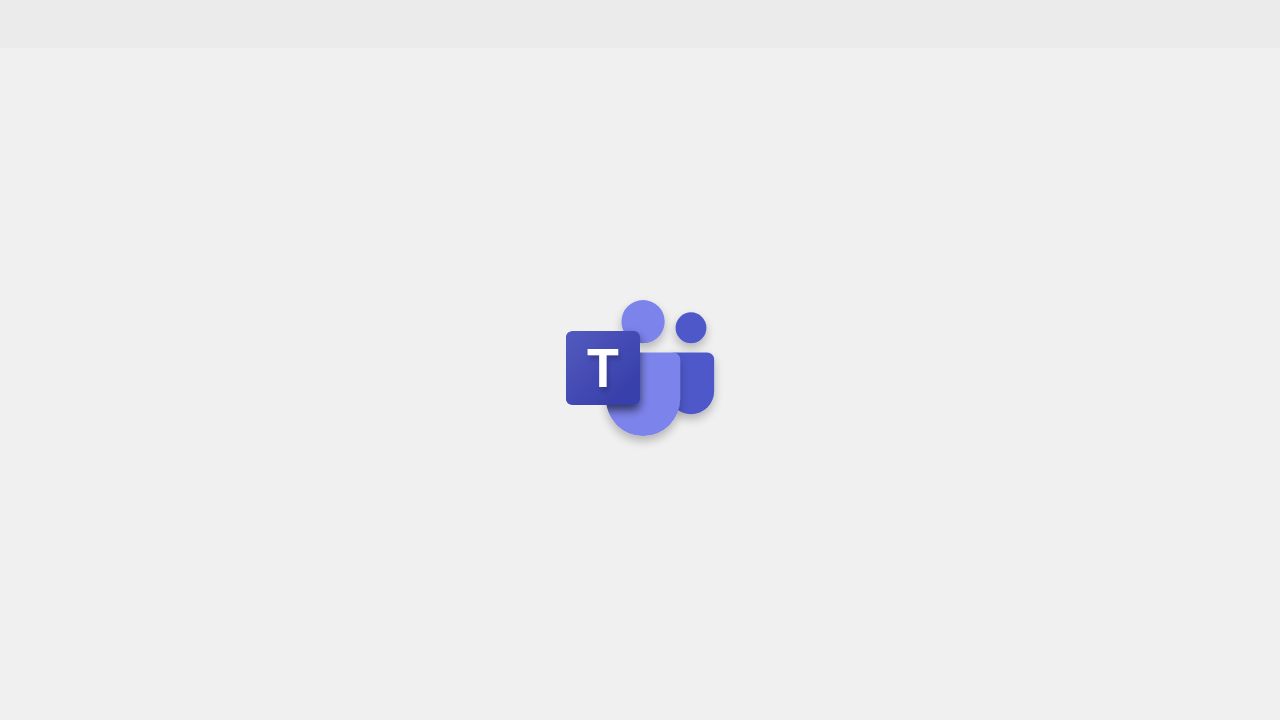

In [ ]:
# @title teams playwright async as func
import asyncio
from playwright.async_api import async_playwright

async def startup(cookies=None):
    browser = await async_playwright().start() # https://github.com/langchain-ai/langchain/discussions/17366
    # browser = await browser.chromium.launch(headless=True, args=None)
    browser = await browser.chromium.launch()
    # page = await browser.new_page()
    context = await browser.new_context()
    context.javaScriptEnabled=True
    if cookies != None: await context.add_cookies(cookies)
    page = await context.new_page()
    return page, context

async def search(page, url):
    await page.goto(url)

async def shutdown():
    await browser.close()

try: page, context = await startup(cookies)
except: page, context = await startup()
url = 'https://teams.microsoft.com/v2/?tenantId=5ba5ef5e-3109-4e77-85bd-cfeb0d347e82'
await search(page, url)

path='/content/screenshot.png'
await page.screenshot(path=path)
from IPython.display import Image, display
display(Image(path))


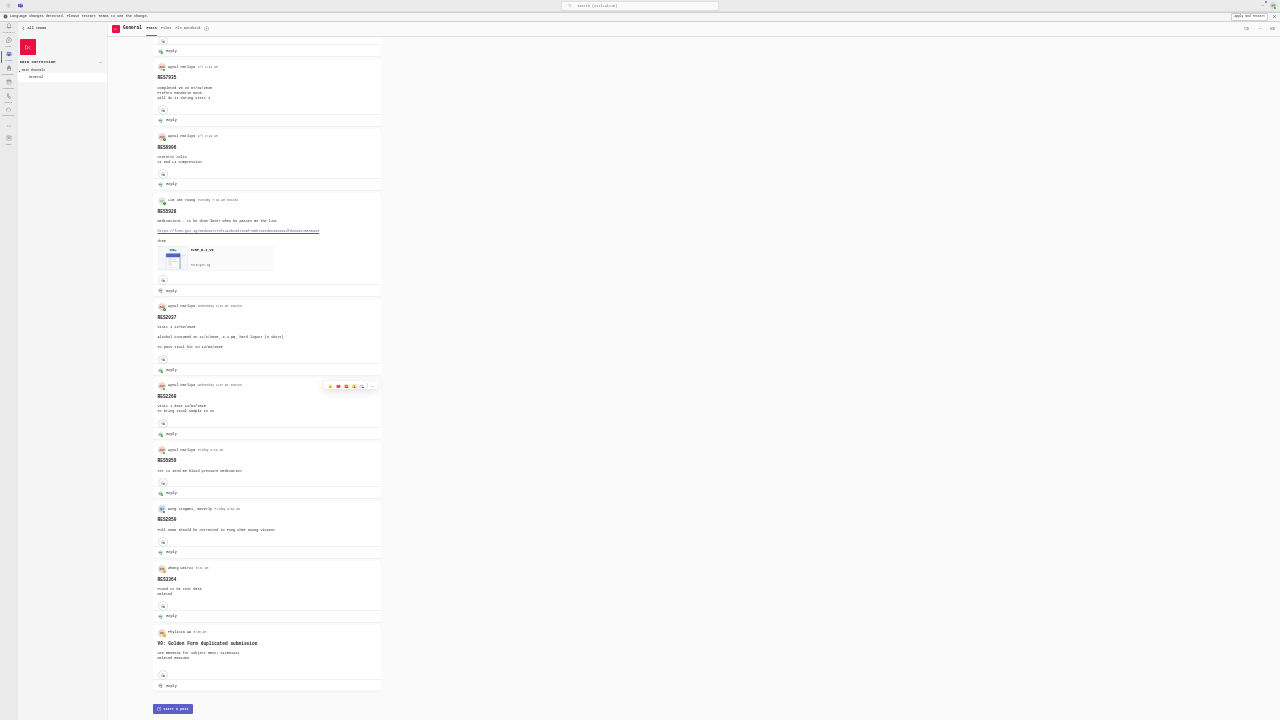

In [ ]:
# @title teams signin

# https://playwright.dev/docs/api/class-mouse
# await page.mouse.move(0, 0)
# await page.mouse.move(50, 50)
# options = {button: 'left'} # left right middle
# await mouse.click(x, y, options)
# await mouse.dblclick(x, y, options)

# await page.mouse.wheel(0, -100) # hori, verti
# # await page.waitForFunction(window.scrollY >= 100)

import time
# https://playwright.dev/docs/api/class-keyboard
# await page.keyboard.type('m.o@nus.edu.sg');
# await page.keyboard.press('Enter');

# time.sleep(1)
# await page.keyboard.press('Shift+Tab');
# await page.keyboard.type('NUSSTF\M.O');
# await page.keyboard.press('Tab');
# await page.keyboard.type('hFLour!sh1ng');
# await page.keyboard.press('Enter');

# await page.keyboard.type('325014');
# await page.keyboard.press('Enter');

# # time.sleep(1)
# await page.get_by_text("Don't show this again").click()
# await page.keyboard.press('Enter');
# cookies = await context.cookies()

# time.sleep(10)
# await page.get_by_text('Data correction').click()
# await page.evaluate("document.body.style.zoom=0.25")

# await page.locator("#message-pane-layout-a11y").click() # F12 > copy > xpath # https://playwright.dev/python/docs/locators#locate-by-css-or-xpath

await page.screenshot(path=path)
display(Image(path))



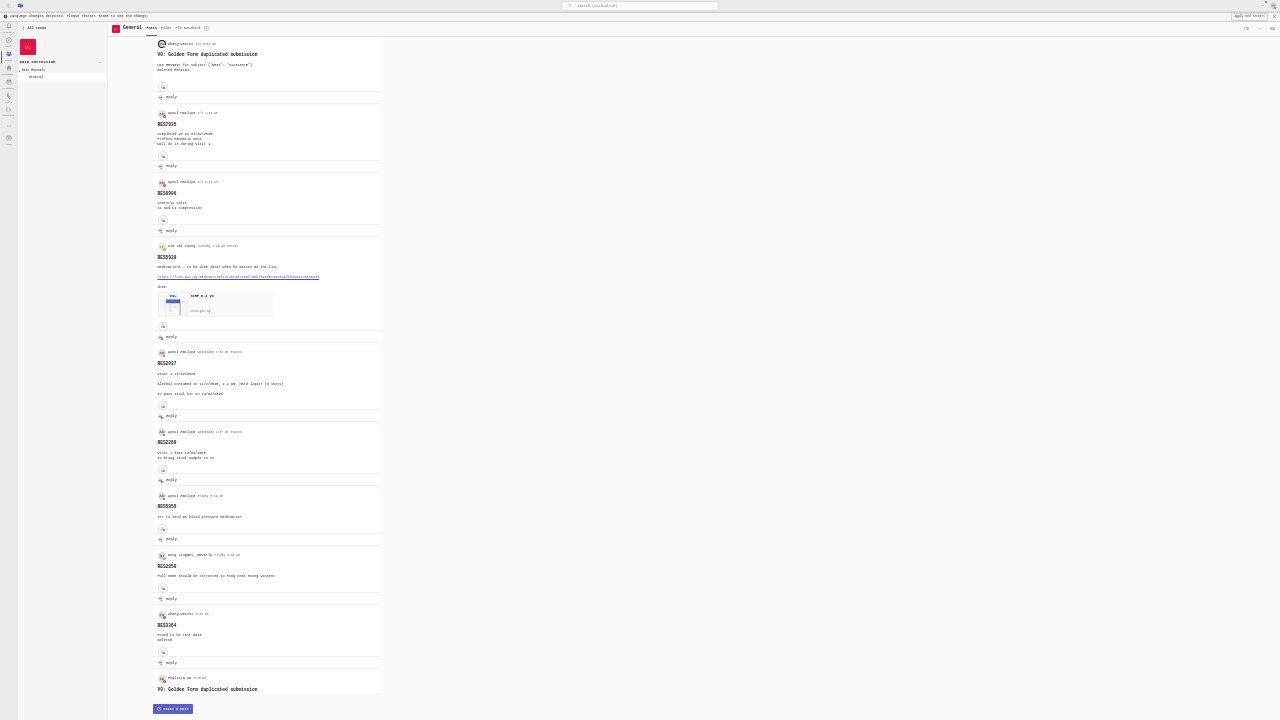

In [ ]:
# https://playwright.dev/python/docs/locators
# for i in range(100):
#     await page.keyboard.press('PageDown');
#     time.sleep(0.1)
#
await page.keyboard.press('PageDown');
# await page.keyboard.press('PageUp');

await page.screenshot(path=path)
display(Image(path))


In [ ]:
# @title test RES0045
def get_boxes(content):
    pro = unquote(content)
    # pro = pro.encode().decode('unicode-escape') # try to remove \\u00
    # print(pro)
    # pattern = r"(?<=data-testid=\"message-body-flex-wrapper\">)(?:(?!</div>).)*(?=</div>)" # after data-testid="message-body-flex-wrapper", no </div>, end with </div>
    pattern = r"(?<=data-testid=\"message-body-flex-wrapper\">)(?:(?!</div>).)*</div>" # after data-testid="message-body-flex-wrapper", no </div>, end with </div> included

    m = re.findall(pattern, pro, re.DOTALL)
    return m

def get_msg(box):
    pattern = r'>([^<>]+)<' # content between '>' and '<' that is longer than ''
    matches = re.findall(pattern, box)
    msg = "\n".join(matches)
    msg = msg.replace('&nbsp;', '').replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">").replace("&quot;", "\"").replace("&apos;", "'")
    # print(msg)
    return msg
    # return matches


content='''<div class="fui-Flex r1wszx8g ___12jwg5y ftuwxu6 f1vx9l62 f1q9h2pe f10kwr27 flypziy fchy9kd fgvoroj f1oy3dpc f1sil6mw f9ijwd5 ffv4pqs fgyim4x f14q3lsm f9jx4fs f19l72ij frnyhdv fkq5uzf fwl63ro f1095u94 fpbf6y8 fy6vjqu fuo4419 fxx2sug f12oply1 fvyt4us f4ki1i f1onj47y f1jrvuk2 f1vrwrd5 f1tandro ff3017q f15llbqz fsaoqmu fcdawxx f1uakdsb f18c6rdl f1ds0vd8 f2yyzyc f1sjbqdg fh1aahx f1g4vdt5 fbzygsp fyy2ueq f1s5r85c f1l4vs6e f10pjld0 fkavt01" data-mid="1728004565001" data-reply-chain-id="1728004565001" data-testid="message-body-flex-wrapper"><h2 dir="auto" as="h2" data-tid="subject-line" id="subject-line-1728004565001" class="fui-StyledText ___z3v47p0 f66ay2y f1aq12i8 f9fewl8 ftfh06i f1amuwu6 f1adrni6">RES0045</h2><div class="fui-Primitive ___77lcry0 f10pi13n"><div id="see-more-content-1728004565001" class="fui-Primitive"><div dir="auto" id="content-1728004565001" data-tid="message-body" class="fui-Primitive">Visit 2 done on 04 Oct 2024 <br><br>
Echo, ECG, etc reports will be saved under RES0945</div></div></div></div>'''
m = get_boxes(content)
print(m)
print(get_msg(m[0]))
content='''<div class="fui-Flex r1wszx8g ___12jwg5y ftuwxu6 f1vx9l62 f1q9h2pe f10kwr27 flypziy fchy9kd fgvoroj f1oy3dpc f1sil6mw f9ijwd5 ffv4pqs fgyim4x f14q3lsm f9jx4fs f19l72ij frnyhdv fkq5uzf fwl63ro f1095u94 fpbf6y8 fy6vjqu fuo4419 fxx2sug f12oply1 fvyt4us f4ki1i f1onj47y f1jrvuk2 f1vrwrd5 f1tandro ff3017q f15llbqz fsaoqmu fcdawxx f1uakdsb f18c6rdl f1ds0vd8 f2yyzyc f1sjbqdg fh1aahx f1g4vdt5 fbzygsp fyy2ueq f1s5r85c f1l4vs6e f10pjld0 fkavt01" data-mid="1727933134867" data-reply-chain-id="1727933134867" data-testid="message-body-flex-wrapper"><h2 dir="auto" as="h2" data-tid="subject-line" id="subject-line-1727933134867" class="fui-StyledText ___z3v47p0 f66ay2y f1aq12i8 f9fewl8 ftfh06i f1amuwu6 f1adrni6">RES3348 V2 reimbursement</h2><div class="fui-Primitive ___77lcry0 f10pi13n"><div id="see-more-content-1727933134867" class="fui-Primitive"><div dir="auto" id="content-1727933134867" data-tid="message-body" class="fui-Primitive"><p>change to&nbsp;</p><p>disburser: Amisha&nbsp;</p></div></div></div></div>'''
m = get_boxes(content)
print(m)
print(get_msg(m[0]))
pattern = r"(?<=start>)(?:(?!end).)*(?=end)"


In [ ]:
# @title scroll and scrape
from urllib.parse import unquote
import re
def get_boxes(content):
    pro = unquote(content)
    # pro = pro.encode().decode('unicode-escape') # try to remove \\u00
    # print(pro)
    # pattern = r"(?<=data-testid=\"message-body-flex-wrapper\">)(?:(?!</div>).)*(?=</div>)" # after data-testid="message-body-flex-wrapper", no </div>, end with </div>
    pattern = r"(?<=data-testid=\"message-body-flex-wrapper\">)(?:(?!</div>).)*</div>" # after data-testid="message-body-flex-wrapper", no </div>, end with </div> included

    m = re.findall(pattern, pro, re.DOTALL)
    return m

def get_msg(box):
    pattern = r'>([^<>]+)<' # content between '>' and '<' that is longer than ''
    matches = re.findall(pattern, box)
    msg = "\n".join(matches)
    msg = msg.replace('&nbsp;', '').replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">").replace("&quot;", "\"").replace("&apos;", "'")
    # print(msg)
    return msg

import time
# # def get_all(page):
all=[]
# last=''
# for i in range(1000):
#     content = await page.content()
#     m = get_boxes(content)
#     print(len(m))
#     for box in reversed(m):
#         msg = get_msg(box)
#         all.insert(0, msg)
#     # if msg==last:
#     if m[0]==last:
#         # print(msg)
#         print("#### ENDED ####")
#         print(last)
#         break
#     else: last=msg
#     await page.keyboard.press('PageUp');
#     # await page.keyboard.press('PageDown');
#     # await page.wait_for_function("document.body.innerHTML !== window.initialHTML", arg={"initialHTML": page.inner_html("body")})
#     # await page.wait_for_selector("#new-content", state="attached")
#     time.sleep(3)
#     # asyncio.sleep(.5)



top=''
for i in range(1000):
    content = await page.content()
    # parse html content to get messages
    m = get_boxes(content)
    print(len(m))
    for box in reversed(m):
        msg = get_msg(box)
        all.insert(0, msg)
    if msg==top:
        # print(msg)
        print("#### ENDED ####")
        print(top)
        break
    else: top=msg

    await page.keyboard.press('PageUp');
    # wait for messages to fully load
    count = 5
    old_m = m
    while True:
        time.sleep(1)
        content = await page.content()
        m = get_boxes(content)
        if m != old_m:
            count = 0
            old_m = m
        else: count += 1
        if count>=5: break

# bottom=''
# for i in range(1000):
#     content = await page.content()
#     m = get_boxes(content)
#     print(len(m))
#     for box in m:
#         msg = get_msg(box)
#         all.append(msg)
#     if msg==bottom:
#         # print(msg)
#         print("#### ENDED ####")
#         print(bottom)
#         break
#     else: bottom=msg
#     await page.keyboard.press('PageDown');
#     time.sleep(3)


# return all



14
23
33
41
40
40
40
38
40
40
41
41
38
40
39
40
40
41
40
41
42
41
41
41
43
44
43
40
42
39
42
43
43
43
47
41
41
#### ENDED ####
https://www.smchealth.org/sites/main/files/file-attachments/moca-instructions-english_2010.pdf


In [ ]:

content = await page.content()
m = get_boxes(content)
print(len(m))
for i, box in enumerate(m):
    msg = get_msg(box)
    print('####', i, '####')
    print(msg)

# await page.keyboard.press('PageDown');
# await page.keyboard.press('PageUp');

await page.screenshot(path=path)
display(Image(path))


In [ ]:
res_save = res
# print(all)
print(len(all)) # 1301
res = []
for msg in all:
    if msg not in res:
        res.append(msg)

print(len(res)) # 331

1466
331


In [ ]:
# for i, msg in enumerate(all):
# for i, msg in enumerate(res):
for i, msg in enumerate(nores):
# for i, msg in enumerate(res_only):
    print('####', i, '####')
    print(msg)

In [ ]:
# res_only=[]
nores=[]
count=0
for msg in res:
    pattern = r'(?i)res\d+' # case insensitive res, imediately followed by a number
    if not re.search(pattern, msg):
        # res_only.append(msg)
        nores.append(msg)

# print(len(res_only)) # 309


In [ ]:
import csv

with open('msgsres2.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_only)

# with open('msgs.csv', newline='') as f:
#     reader = csv.reader(f)
#     res291 = list(reader)[0]

# print(res)
# print(len(res))

In [ ]:
print(res)


['https://www.smchealth.org/sites/main/files/file-attachments/moca-instructions-english_2010.pdf', 'MoCA Notes &amp; Example MoCA test ', 'contact (mail and others), moca, sex at birth, drinks, gender, Qualtrics to follow up', 'forms updates\nhttps://form.gov.sg/659671ecb70a3e001140628f\nGolden form updated for contact to include mail and mail address (mandatory for when selecting mail btw)\n\nhttps://form.gov.sg/65d33445ba50eef89edf7264?65dc4d5e540c2676f8ba8b46=606Q&amp;65b761dd7ed92f92507a8290\nB1 form updated for:\nSex at birth\nGender\nDrinker (questions and logics)\nSmoker (questions and logics)\n\nhttps://form.gov.sg/653a2be9592fd400111c0748\nPre-screening form updated for:\nsex at birth question and answer\nwhere did you hear about us? (but waiting for updates about checkbox options)\n\n', 'Data Corrections\neCRF (formsg)\nRES2276 need to update the database to include congenital heart disease\nRES1953 NOK r/s was wrongly input as "son". Correct input is "cousin"\nRES0383 missin

## save

In [ ]:
# @title playwright save
# https://github.com/microsoft/playwright-python
import asyncio
from playwright.async_api import async_playwright

path='/content/screenshot.png'
async def main(url):
    async with async_playwright() as p:
        browser_type = p.firefox # p.chromium, p.firefox, p.webkit
        browser = await browser_type.launch()
        page = await browser.new_page()
        await page.goto(url)
        await page.screenshot(path=path)
        await browser.close()

# url = 'http://playwright.dev'
# asyncio.run(main(url)) # in script
await main(url) # in colab

from IPython.display import Image, display
display(Image(path))


In [ ]:
# @title playwright class like save
# url = 'https://www.dictionary.com/browse/e'
url = 'https://pypi.org/project/playwright/'

async def startup():
    browser = await async_playwright().start() # https://github.com/langchain-ai/langchain/discussions/17366
    # browser = await browser.chromium.launch(headless=True, args=None)
    browser = await browser.chromium.launch()
    page = await browser.new_page()
    return page

async def search(page, url):
    await page.goto(url)
    await page.screenshot(path=path)

async def shutdown():
    await browser.close()

page = await startup()
await main(page, url)

from IPython.display import Image, display
display(Image(path))



In [ ]:
# @title uBlock
# https://github.com/microsoft/playwright-python/issues/782
# https://github.com/gorhill/uBlock
# https://github.com/gorhill/uBlock/tree/master/dist#install
ubo_url = 'https://github.com/gorhill/uBlock/releases/download/1.58.0/uBlock0_1.58.0.chromium.zip'
response = requests.get(ubo_url)
with open('ublock.zip', 'wb') as f:
    f.write(response.content)
!unzip ublock.zip


In [ ]:
# @title async_playwright
from playwright.async_api import async_playwright

path_to_extension = "./uBlock0.chromium"
user_data_dir = "/tmp/test-user-data-dir"
async def startup():
    p = await async_playwright().start()
    context = await p.chromium.launch_persistent_context(user_data_dir, headless=True,
        args=[f"--disable-extensions-except={path_to_extension}",
              f"--load-extension={path_to_extension}",],) # <BrowserContext browser=None>
    # background_page = context.background_pages
    page = context.pages[0] # <Page url='about:blank'>
    page.wait_for_timeout(1000) # wait until uBlock Origin is initialised
    return page

async def search(page, url):
    await page.goto(url)
    await page.screenshot(path=path)

async def shutdown():
    await browser.close()


url = 'https://www.justwatch.com/us'

page = await startup()
await search(page, url)

from IPython.display import Image, display
display(Image(path))



In [ ]:
# @title async handle_response

import os
from playwright.sync_api import sync_playwright
url = "https://twitter.com/rihanna"
content_length_threshold = 100
with sync_playwright() as p:
    def handle_response(response):
        try:
            if (response.ok # successful response (status in the range 200-299)
            and response.request.resource_type == "image" # it is of type image
            and int(response.all_headers().get('content-length', 0)) > content_length_threshold # bigger than our threshold
            ):
                # avoid "[Errno 36] File name too long"
                filename = os.path.basename(response.url)[-120:]
                f = open(filename, "wb")
                f.write(response.body())
                f.close()
        except Exception as e:
            print(e)
    browser = p.chromium.launch()
    page = browser.new_page()
    page.on("response", handle_response)
    page.goto(url)
    page.keyboard.press("End") # go to the end of the page
    page.wait_for_load_state("networkidle") # wait until the images are loaded
    # in case we want the links to continue crawling
    links = page.eval_on_selector_all("a[href^='/']", "links => links.map(link => link.href)")
    page.context.close()
    browser.close()


# from selenium_house
def scroll_end(driver):
    end = driver.find_elements(By.XPATH,'''*//div[@data-endedmessage="Looks like you've reached the end"]''')[0]#.click()
    while end.get_attribute("data-status") != "3": # =5, =3 when reach end
        more = driver.find_elements(By.XPATH,"*//input[@value='Show more results']")[0]#.click()
        if more.is_displayed(): more.click()
        # height = driver.execute_script("return document.body.scrollHeight")
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);") # scroll down

def click_all(driver):
    see_more=[]
    hits = driver.find_elements(By.XPATH,"*//a[@class='wXeWr islib nfEiy']")
    driver.execute_script("hits = document.getElementsByClassName('wXeWr islib nfEiy')")
    print(len(hits)) # 780
    # for i, x in enumerate(hits):
    for i in range(len(hits)):
        # hits[i].click()
        driver.execute_script("hits["+str(i)+"].click();")
        try:
            WebDriverWait(driver, 3).until(EC.presence_of_element_located((By.XPATH, "*//a[@aria-label='See more Related content']")))
            see_mor = driver.find_elements(By.XPATH,"*//a[@aria-label='See more Related content']")[0].get_attribute("href")
        except: see_mor="_"
        see_more.append(see_mor)
    return see_more

from urllib.parse import unquote
import re
def get_imgurls(driver):
    pro=driver.page_source
    # pro=driver.execute_script("return document.documentElement.outerHTML")
    pro = unquote(pro)
    pro = pro.encode().decode('unicode-escape') # try to remove \\u00
    # pattern = r"https://(?:(?!\").)*\.jpg" # start with https:// , no " , end with .jpg # https://stackoverflow.com/a/67540659/13359815
    pattern = r"(?<=href=\"/imgres\?imgurl=)(?:(?!&amp;).)*(?=&amp;)" # start with href="/imgres?imgurl= , no &amp; , end with &amp; # https://stackoverflow.com/a/3926546/13359815
    # pattern = r"https://(?:(?!\").)*(?=\")" # start with https:// , no " , end with " # all urls
    # pattern = r"(?<=\],\[\")https://(?:(?!\").)*(?=\")" # start with ],[" then https:// , no " , end with " # all imgs? fast
    m = re.findall(pattern, pro)
    return m



In [ ]:
# @title mouse, screen size
# https://playwright.dev/docs/api/class-mouse
# await page.mouse.move(0, 0)
# await page.mouse.move(50, 50)
# options = {button: 'left'} # left right middle
# await mouse.click(x, y, options)
# await mouse.dblclick(x, y, options)


# await page.mouse.wheel(0, 100) # hori, verti
# # await page.waitForFunction(window.scrollY >= 100)

# await page.screenshot(path=path)
# from IPython.display import Image, display
# display(Image(path))


# https://playwright.dev/python/docs/emulation






# print(await page.content())
text = await page.content()
soup = BeautifulSoup(text, features="html.parser")

for script in soup(["script", "style"]):
    script.extract()
    script.decompose()

text = soup.get_text()
lines = (line.strip() for line in text.splitlines())
chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
formatted_text = "\n".join(chunk for chunk in chunks if chunk)

print(formatted_text)



In [ ]:
# @title lxml trash
content = await page.content()


from lxml import html
doc = html.fromstring(content)
boxes = doc.xpath('//div[@data-testid="message-body-flex-wrapper"]') # *//div[@data-testid="message-body-flex-wrapper"]


def get_box_text(element):
    texts = []
    # The XPath 'node()' retrieves all child nodes (both text and element nodes).
    for node in element.xpath('node()'):
        if isinstance(node, str):
            # This node is a text node.
            text = node.strip()
            if text:
                texts.append(text)
        else:
            # This node is an element. Get its text content (including its nested children).
            text = node.text_content().strip()
            if text:
                texts.append(text)
    return "\n".join(texts)


def get_box_text(box):
    # Iterate over direct child elements of the box
    texts = []
    for child in box.xpath('./*'):
        # Retrieve the full text (including nested text) and strip whitespace
        child_text = child.text_content().strip()
        if child_text:  # Only include if there is text
            texts.append(child_text)
    # Join the texts with a newline between siblings that both have text
    return "\n".join(texts)

for i, box in enumerate(boxes, start=1):
    # text = box.text_content()  # This method gathers all text from the element and its descendants
    # # print(f"Box {i} text: {text.strip()}")
    # texts = [child.text_content().strip() for child in box.iterdescendants() if child.text_content().strip()]
    # texts = [child.text_content().strip() for child in box.xpath('./*') if child.text_content().strip()]
    # box_text = "\n".join(texts)
    # box_text = get_box_text(box)
    box_text='\n'.join([child.text_content() for child in box.xpath('./*')])

    print(i, box_text)

# await page.keyboard.press('PageUp');


# print(box) # <Element div at 0x7c49b45ba170>
# print(box.text_content()) # RES2260, RES2037Visit 1 date 12/02/2025To bring stool sample in v2

for child in box.xpath('node()'):
# for child in box.xpath('./*'):
    # print(child)
    print(child.text_content())

# out ='\n'.join([child.text_content() for child in box.xpath('./*')])
# print(out)

# <Element h2 at 0x7c49b61f0550>
# <Element div at 0x7c49b45e5270>

# print(vars(child))
# object_methods = [method_name for method_name in dir(child) if callable(getattr(child, method_name))]
# print(object_methods)
print(child.getchildren())
print(child.getchildren()[0].text_content())



In [ ]:
# @title get cookies


cookies = await context.cookies()
print(cookies)
import json
from pathlib import Path
# Path("cookies.json").write_text(json.dumps(cookies))
# with open("cookies.json", "w") as f:
#     f.write(json.dumps(context.cookies()))

# # Then, we can restore cookies from file:
# context = browser.new_context(viewport={"width": 1920, "height": 1080})
# context.add_cookies(json.loads(Path("cookies.json").read_text()))


# # Load the cookies
# with open("cookies.json", "r") as f:
#     cookies = json.loads(f.read())
#     context.add_cookies(cookies)


[{'name': 'clocale', 'value': 'en-us', 'domain': 'teams.microsoft.com', 'path': '/', 'expires': 1771308648.369105, 'httpOnly': True, 'secure': True, 'sameSite': 'Lax'}, {'name': 'MUIDB', 'value': '0E835FCE8CA76BF213D54A588DD26A11', 'domain': 'teams.microsoft.com', 'path': '/', 'expires': 1773468648.369342, 'httpOnly': True, 'secure': True, 'sameSite': 'Lax'}]


361